In [1]:
import pandas as pd
import numpy as np
import os
import sys
# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.libs_generic_functions import LibsDataLoader
from utils.saturation_functions import run_complete_saturation_analysis, diagnose_data_structure, apply_voigt_saturation_correction, plot_voigt_correction_examples, validate_voigt_corrections

In [2]:
dataloader = LibsDataLoader(data_directory = "../data")

In [3]:
df = dataloader.load_all_measurements_no_rounding()

MEMORY-EFFICIENT LOADING OF ALL INDIVIDUAL MEASUREMENTS
First pass: Counting measurements...
Processing file 1/316: 2024-11-05T11-26-41_nr-001_B1_tread_aided_10Hz_280A.h5
Processing file 11/316: 2024-11-05T11-51-23_nr-011_B4_innerliner_aided_10Hz_280A.h5
Processing file 21/316: 2024-11-05T12-02-34_nr-021_B7_sidewall_aided_10Hz_280A.h5
Processing file 31/316: 2024-11-05T12-13-30_nr-031_B22_tread_aided_10Hz_280A.h5
Processing file 41/316: 2024-11-05T12-25-42_nr-041_B33_innerliner_aided_10Hz_280A.h5
Processing file 51/316: 2024-11-05T12-36-31_nr-051_B28_sidewall_aided_10Hz_280A.h5
Processing file 61/316: 2024-11-05T12-47-29_nr-061_B15_tread_aided_10Hz_280A.h5
  Counted 10,000 measurements...
Processing file 71/316: 2024-11-05T12-58-45_nr-071_B30_innerliner_aided_10Hz_280A.h5
Processing file 81/316: 2024-11-05T13-17-11_nr-081_B35_innerliner_aided_10Hz_280A.h5
Processing file 91/316: 2024-11-05T14-05-16_nr-091_B26_sidewall_aided_10Hz_280A.h5


Processing file 101/316: 2024-11-05T14-16-52_nr-101_B16_tread_aided_10Hz_280A.h5
Processing file 111/316: 2024-11-05T14-27-46_nr-111_B27_innerliner_aided_10Hz_280A.h5
Processing file 121/316: 2024-11-05T14-38-38_nr-121_B20_sidewall_aided_10Hz_280A.h5
Processing file 131/316: 2025-01-14T10-56-26_nr-009_B96_sidewall_aided_10Hz_280A.h5
Processing file 141/316: 2025-01-14T11-27-57_nr-019_B88_sidewall_aided_10Hz_280A.h5
  Counted 20,000 measurements...
Processing file 151/316: 2025-01-14T11-45-53_nr-008_B81_innerliner_aided_10Hz_280A.h5
Processing file 161/316: 2025-01-14T11-58-54_nr-018_B103_innerliner_aided_10Hz_280A.h5
Processing file 171/316: 2025-01-14T12-50-37_nr-028_B98_sidewall_aided_10Hz_280A.h5
Processing file 181/316: 2025-01-14T13-04-29_nr-038_B84_innerliner_aided_10Hz_280A.h5
Processing file 191/316: 2025-01-14T13-18-00_nr-049_B94_tread_aided_10Hz_280A.h5
Processing file 201/316: 2025-01-14T13-31-51_nr-059_B85_sidewall_aided_10Hz_280A.h5
Processing file 211/316: 2025-01-14T13-5

In [4]:
df.head()

,200.000,200.098,200.195,200.293,200.391,200.489,200.586,200.684,200.782,200.879,...,999.414,999.511,999.609,999.707,999.805,999.902,1000.000,origin,tire_number,measurement_id
0,201.0,156.0,249.0,195.0,271.0,142.0,240.0,232.0,225.0,165.0,...,480.0,524.0,480.0,512.0,452.0,534.0,458.0,tread,1,0
1,166.0,124.0,208.0,104.0,209.0,91.0,232.0,168.0,202.0,138.0,...,545.0,550.0,524.0,623.0,529.0,606.0,503.0,tread,1,1
2,200.0,181.0,282.0,183.0,276.0,158.0,224.0,187.0,221.0,176.0,...,486.0,520.0,458.0,536.0,423.0,549.0,422.0,tread,1,2
3,143.0,113.0,160.0,118.0,203.0,71.0,200.0,130.0,195.0,145.0,...,536.0,575.0,532.0,651.0,525.0,624.0,527.0,tread,1,3
4,235.0,162.0,237.0,196.0,255.0,147.0,301.0,266.0,254.0,225.0,...,484.0,541.0,479.0,583.0,484.0,556.0,472.0,tread,1,4


🔍 Diagnosing data structure...
🔍 DIAGNOSTIC INFORMATION
DataFrame shape: (51453, 8191)
Column count: 8191
Column names sample: ['200.000', '200.098', '200.195', '200.293', '200.391', '200.489', '200.586', '200.684', '200.782', '200.879']
Data types: {dtype('float32'): 8188, dtype('int32'): 2, dtype('O'): 1}

Wavelength columns detected: 8188
Sample wavelength columns: ['200.000', '200.098', '200.195', '200.293', '200.391']

Intensity statistics:
Min value: 19.0
Max value: 65535.0
Mean value: 8879.21
Values >= 50000: 706928 (0.1678%)
Values >= 60000: 272207 (0.0646%)
Values >= 65535: 158347 (0.0376%)
🔍 Starting comprehensive saturation analysis...
🔍 Saturation Analysis (threshold: 65535)
Total measurements: 51453
Total wavelengths: 8188

📊 Overall Saturation Statistics:
   Total intensity values: 421,297,164
   Saturated values: 158,347
   Saturation percentage: 0.0376%

🔬 Measurement-Level Analysis:
   Measurements with saturation: 14224/51453
   Percentage of affected measurements: 27

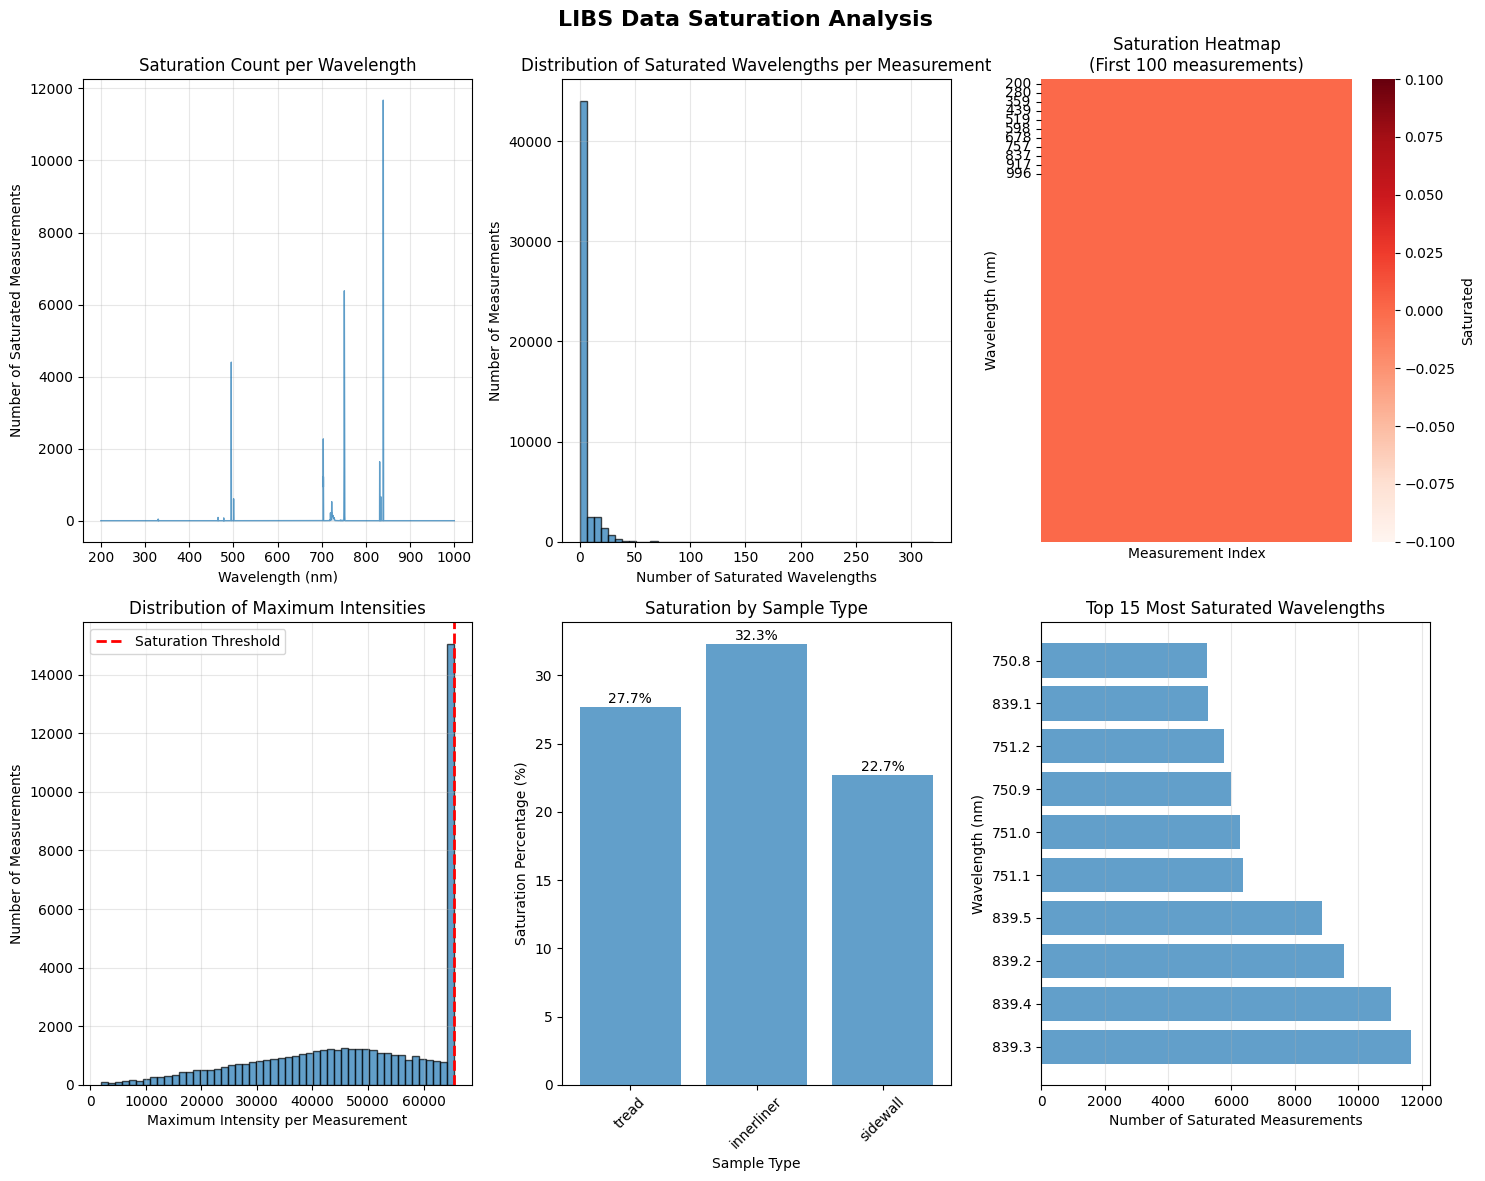


🚨 Identifying problematic measurements and wavelengths...

🚨 Data Quality Assessment (threshold: 5.0% saturation)
📊 Problematic Measurements:
   Measurements with >5.0% wavelength saturation: 0/51453
   Percentage of dataset: 0.00%

🌊 Problematic Wavelengths:
   Wavelengths with >5.0% measurement saturation: 19/8188
   Percentage of spectrum: 0.23%

💡 Recommendations:
   ⚡ Moderate saturation detected - manageable with preprocessing
   💡 Consider removing 19 problematic wavelengths

   🔍 Worst 5 wavelengths to consider removing:
      λ839.257: 22.7% saturated
      λ839.355: 21.5% saturated
      λ839.160: 18.6% saturated
      λ839.453: 17.2% saturated
      λ751.118: 12.4% saturated

📋 Summary:
✅ Excellent data quality - minimal saturation detected
Overall saturation: 0.0376%
Affected measurements: 27.64%
Affected wavelengths: 4.59%
CPU times: total: 16.4 s
Wall time: 13.4 s


In [5]:
%%time

# Run diagnostic first (optional)
print("🔍 Diagnosing data structure...")
diagnose_data_structure(df)

# Run complete saturation analysis
analysis_results = run_complete_saturation_analysis(
    df=df,
    saturation_threshold=65535,
    severity_threshold=0.05,
    plot=True,
    figsize=(15, 12),
    save_plot=None  # Set to a file path if you want to save
)

## De Voigt functie

Om de saturation tegen te gaan, gaan we de Voigt functie toepassen op de oververzadigde pieken. De Voigt functie is een convolutie van een Gaussische en een Lorentzische functie, wat resulteert in een betere modellering van de pieken in spectrale data. Deze functie houdt rekening met zowel de Doppler-breedte (Gaussisch) als de druk-breedte (Lorentzisch) van de pieken, wat leidt tot een nauwkeurigere weergave van de werkelijke spectrale lijnen, vooral in gevallen van oververzadiging.
De formule luidt:

$$ V(x; \sigma, \gamma) \equiv \int_{-\infty}^{\infty} G(x'; \sigma) L(x - x'; \gamma) \, dx' $$

Dit is een convolutie van twee functies:
- De Gaussische functie:
    $ G(x; \sigma) \equiv \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{x^2}{2\sigma^2}} $

- De Lorentzische functie:
    $ L(x; \gamma) \equiv \frac{\gamma}{\pi (x^2 + \gamma^2)} $


Het resultaat wordt de Voigt-profiel genoemd. $$ V(x; \sigma, \gamma)\ $$  

### Termen van de Voigt functie

1. $ x $

    De variabele waarop de functie wordt geëvalueerd, vaak gerelateerd aan golflengte of frequentie in spectrale data.

2. $ \sigma $

    De standaarddeviatie van de Gaussische component, die de breedte van de Gaussische piek bepaalt. 
    Een grotere $ \sigma $ resulteert in een bredere Gaussische piek.

3. $ \gamma $

    De half-hoogte breedte van de Lorentzische component, die de breedte van de Lorentzische piek bepaalt. Een grotere $ \gamma $ resulteert in langere vleugels en trager verval van de intenstiteit, oftewel een bredere piek.

4. $ G(x'; \sigma) $ en $ L(x - x'; \gamma) $

    Deze functies worden geconvolueerd, wat betekent dat je kijkt naar hoe de ene functie versmeerd wordt door de andere

5. $ V(x; \sigma, \gamma) $

    Het resultaat van de convolutie, wat de gecombineerde effecten van zowel de Gaussische als de Lorentzische breedte op de piek weergeeft. Er bestaat geen eenvoudige analytische uitdrukking voor de Voigt-functie, maar het kan efficiënt worden berekend met behulp van de Faddeeva-functie:
$ V(x; \sigma, \gamma) = \frac{\text{Re}[w(z)]}{\sigma \sqrt{2\pi}} $
waarbij $ z = \frac{x + i\gamma}{\sigma \sqrt{2}} $ en $ w(z) $ de Faddeeva-functie is.

In [6]:
df_corrected = apply_voigt_saturation_correction(df, verbose=True)


🔧 Voigt Profile Saturation Correction
Total measurements: 51453
Saturated measurements: 14224
Processing measurements: 14224
Saturation threshold: 65535
Minimum peak width: 3


Progress: 1422/14224 (10.0%)
Progress: 2844/14224 (20.0%)
Progress: 4266/14224 (30.0%)
Progress: 5688/14224 (40.0%)
Progress: 7110/14224 (50.0%)
Progress: 8532/14224 (60.0%)
Progress: 9954/14224 (70.0%)
Progress: 11376/14224 (80.0%)
Progress: 12798/14224 (90.0%)
Progress: 14220/14224 (100.0%)

📊 Correction Summary:
------------------------------
Measurements processed: 14224
Measurements corrected: 11325
Success rate: 79.6%
Total peaks found: 20942
Total peaks corrected: 20915
Peak correction rate: 99.9%

Intensity ranges:
Original max: 65,535
Corrected max: 1,287,537
Max increase: 19.65x


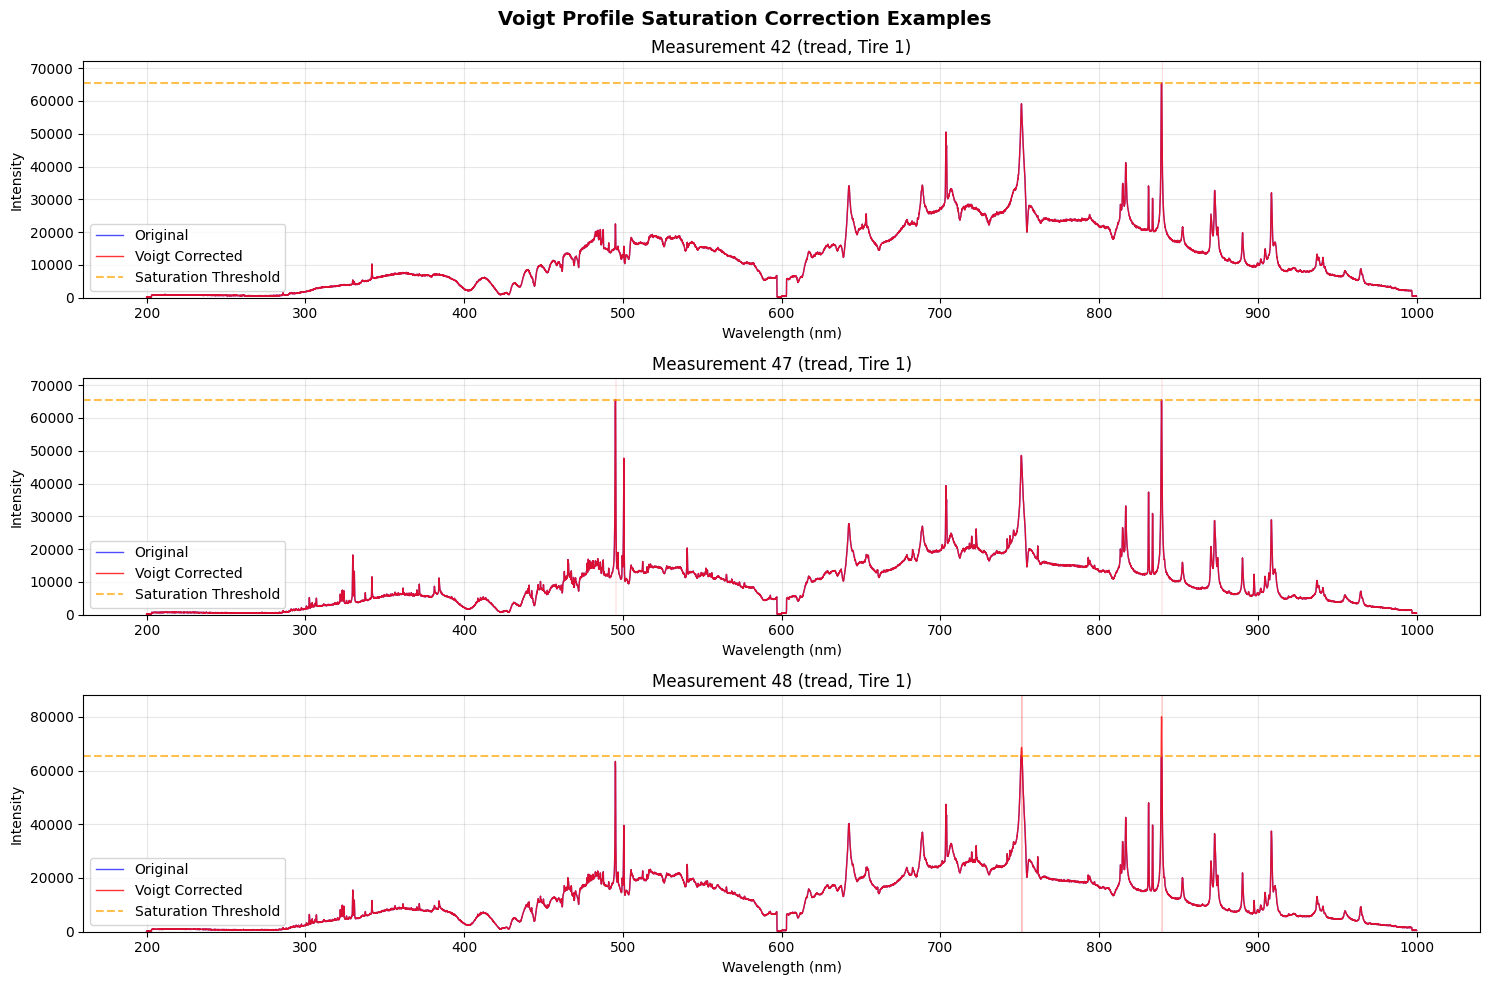

In [7]:
# Plot examples of corrections
plot_voigt_correction_examples(df, df_corrected, n_examples=3)


In [8]:

# Validate correction quality
validation = validate_voigt_corrections(df, df_corrected)


✅ Voigt Correction Validation:
----------------------------------------
Originally saturated values: 158,347
Values changed by correction: 144,879
Correction coverage: 91.5%
Mean correction ratio: 1.15x
Max correction ratio: 19.65x
Original max intensity: 65,535
Corrected max intensity: 1,287,537
🎉 Excellent correction coverage!


🚀 Running simple outlier analysis...
🔍 SIMPLE OUTLIER ANALYSIS - CORRECTED LIBS DATA
🏆 TOP 10 HIGHEST INTENSITY VALUES:
----------------------------------------
2020. Measurement 47 (innerliner):
    Tire: 4
    λ703.725: 1,287,537

2119. Measurement 146 (innerliner):
    Tire: 4
    λ703.725: 1,260,318

2121. Measurement 148 (innerliner):
    Tire: 4
    λ703.725: 1,244,909

11119. Measurement 131 (innerliner):
    Tire: 40
    λ723.562: 766,392

11098. Measurement 110 (innerliner):
    Tire: 40
    λ724.148: 463,234

11039. Measurement 51 (innerliner):
    Tire: 40
    λ724.148: 462,573

11096. Measurement 108 (innerliner):
    Tire: 40
    λ724.148: 456,083

11024. Measurement 36 (innerliner):
    Tire: 40
    λ724.148: 447,493

11060. Measurement 72 (innerliner):
    Tire: 40
    λ724.148: 442,942

11080. Measurement 92 (innerliner):
    Tire: 40
    λ724.148: 434,079

📊 INTENSITY STATISTICS:
------------------------------
Mean intensity per measurement:
   Min: 484
   Max: 19,643


C:\Users\joost\AppData\Local\Temp\ipykernel_10596\3151414046.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax1.boxplot(plot_data, labels=plot_labels, patch_artist=True)
C:\Users\joost\AppData\Local\Temp\ipykernel_10596\3151414046.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=violin_df, x='sample_type', y='mean_intensity', ax=ax2, palette='Set2')


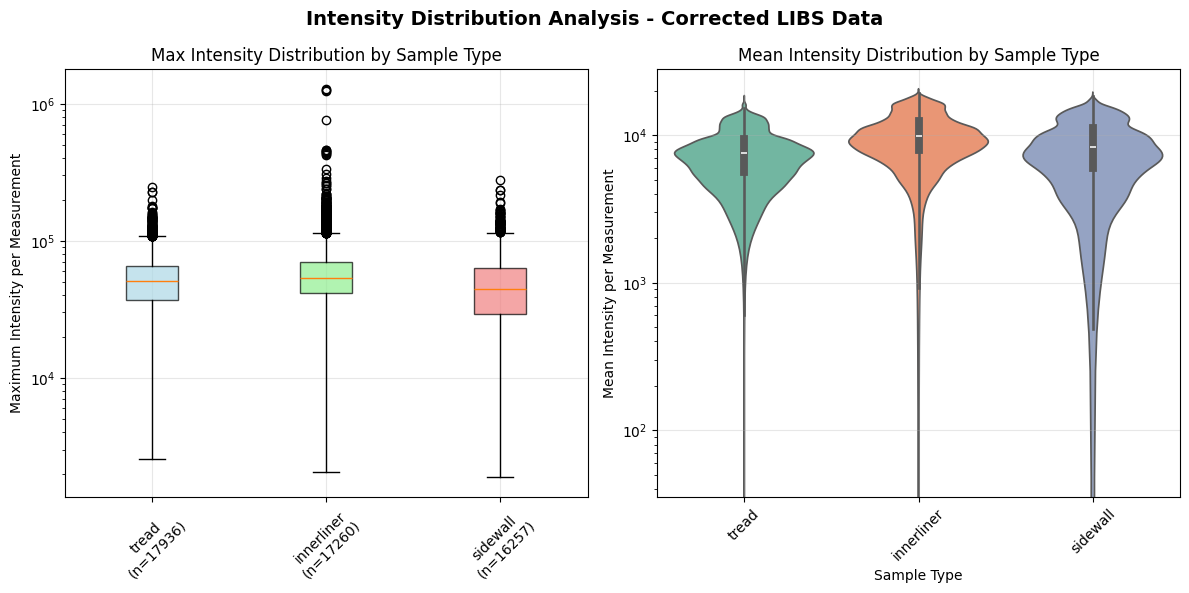


📋 SUMMARY BY SAMPLE TYPE:
----------------------------------------
tread:
   Measurements: 17936
   Max intensity range: 2,579 - 245,681
   Mean intensity range: 601 - 17,741
   Potential outliers (>95th percentile): 897

innerliner:
   Measurements: 17260
   Max intensity range: 2,043 - 1,287,537
   Mean intensity range: 488 - 19,643
   Potential outliers (>95th percentile): 863

sidewall:
   Measurements: 16257
   Max intensity range: 1,876 - 279,787
   Mean intensity range: 484 - 18,535
   Potential outliers (>95th percentile): 813



In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def simple_outlier_analysis(df_corrected, plot=True, figsize=(12, 6)):
    """
    Simple outlier analysis with box/violin plots and top intensity values.
    
    Parameters:
    -----------
    df_corrected : pd.DataFrame
        Corrected DataFrame after Voigt saturation correction
    plot : bool, default=True
        Whether to generate plots
    figsize : tuple, default=(12, 6)
        Figure size for plots
    """
    
    print("🔍 SIMPLE OUTLIER ANALYSIS - CORRECTED LIBS DATA")
    print("=" * 60)
    
    # Get wavelength columns
    wavelength_columns = [col for col in df_corrected.columns 
                         if col not in ['tire_number', 'origin', 'measurement_id', 'sample_type']]
    
    if len(wavelength_columns) == 0:
        print("❌ No wavelength columns found!")
        return
    
    # Find the 10 highest intensity values across the entire dataset
    print("🏆 TOP 10 HIGHEST INTENSITY VALUES:")
    print("-" * 40)
    
    max_values = []
    
    # Iterate through all measurements to find highest intensities
    for idx, row in df_corrected.iterrows():
        measurement_id = row.get('measurement_id', idx)
        tire_number = row.get('tire_number', 'Unknown')
        origin = row.get('origin', 'Unknown')
        
        # Get intensity values for this measurement
        intensities = row[wavelength_columns].values
        
        # Find max intensity and corresponding wavelength
        max_intensity = intensities.max()
        max_wavelength_idx = intensities.argmax()
        max_wavelength = wavelength_columns[max_wavelength_idx]
        
        max_values.append({
            'measurement_id': measurement_id,
            'tire_number': tire_number,
            'origin': origin,
            'wavelength': max_wavelength,
            'intensity': max_intensity
        })
    
    # Sort by intensity and get top 10
    max_values_df = pd.DataFrame(max_values)
    top_10 = max_values_df.nlargest(10, 'intensity')
    
    for i, row in top_10.iterrows():
        print(f"{i+1:2d}. Measurement {row['measurement_id']} ({row['origin']}):")
        print(f"    Tire: {row['tire_number']}")
        print(f"    λ{row['wavelength']}: {row['intensity']:,.0f}")
        print()
    
    # Calculate basic statistics for plotting
    print("📊 INTENSITY STATISTICS:")
    print("-" * 30)
    
    X = df_corrected[wavelength_columns].values
    mean_intensities = X.mean(axis=1)
    max_intensities = X.max(axis=1)
    
    print(f"Mean intensity per measurement:")
    print(f"   Min: {mean_intensities.min():,.0f}")
    print(f"   Max: {mean_intensities.max():,.0f}")
    print(f"   Median: {np.median(mean_intensities):,.0f}")
    print(f"   Std: {mean_intensities.std():,.0f}")
    
    print(f"\nMax intensity per measurement:")
    print(f"   Min: {max_intensities.min():,.0f}")
    print(f"   Max: {max_intensities.max():,.0f}")
    print(f"   Median: {np.median(max_intensities):,.0f}")
    print(f"   Std: {max_intensities.std():,.0f}")
    
    if plot:
        # Create plots
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        fig.suptitle('Intensity Distribution Analysis - Corrected LIBS Data', fontsize=14, fontweight='bold')
        
        # Prepare data for sample type analysis if available
        sample_type_col = None
        if 'origin' in df_corrected.columns:
            sample_type_col = 'origin'
        elif 'sample_type' in df_corrected.columns:
            sample_type_col = 'sample_type'
        
        # Box plot
        ax1 = axes[0]
        if sample_type_col:
            # Create data for box plot by sample type
            plot_data = []
            plot_labels = []
            sample_types = df_corrected[sample_type_col].unique()
            
            for sample_type in sample_types:
                mask = df_corrected[sample_type_col] == sample_type
                sample_max_intensities = max_intensities[mask]
                plot_data.append(sample_max_intensities)
                plot_labels.append(f"{sample_type}\n(n={len(sample_max_intensities)})")
            
            box_plot = ax1.boxplot(plot_data, labels=plot_labels, patch_artist=True)
            
            # Color the boxes
            colors = ['lightblue', 'lightgreen', 'lightcoral']
            for patch, color in zip(box_plot['boxes'], colors[:len(plot_data)]):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
                
            ax1.set_title('Max Intensity Distribution by Sample Type')
            ax1.set_ylabel('Maximum Intensity per Measurement')
            ax1.tick_params(axis='x', rotation=45)
        else:
            # Single box plot for all data
            ax1.boxplot([max_intensities], labels=['All Measurements'])
            ax1.set_title('Max Intensity Distribution')
            ax1.set_ylabel('Maximum Intensity per Measurement')
        
        ax1.grid(True, alpha=0.3)
        ax1.set_yscale('log')  # Log scale due to large range
        
        # Violin plot
        ax2 = axes[1]
        if sample_type_col:
            # Prepare data for violin plot
            violin_data = []
            for sample_type in sample_types:
                mask = df_corrected[sample_type_col] == sample_type
                sample_mean_intensities = mean_intensities[mask]
                
                # Add sample type column for seaborn
                temp_df = pd.DataFrame({
                    'mean_intensity': sample_mean_intensities,
                    'sample_type': sample_type
                })
                violin_data.append(temp_df)
            
            violin_df = pd.concat(violin_data, ignore_index=True)
            
            sns.violinplot(data=violin_df, x='sample_type', y='mean_intensity', ax=ax2, palette='Set2')
            ax2.set_title('Mean Intensity Distribution by Sample Type')
            ax2.set_xlabel('Sample Type')
            ax2.set_ylabel('Mean Intensity per Measurement')
            ax2.tick_params(axis='x', rotation=45)
        else:
            # Single violin plot
            violin_df = pd.DataFrame({'mean_intensity': mean_intensities})
            sns.violinplot(data=violin_df, y='mean_intensity', ax=ax2)
            ax2.set_title('Mean Intensity Distribution')
            ax2.set_ylabel('Mean Intensity per Measurement')
        
        ax2.grid(True, alpha=0.3)
        ax2.set_yscale('log')  # Log scale due to large range
        
        plt.tight_layout()
        plt.show()
        
        # Summary by sample type if available
        if sample_type_col:
            print(f"\n📋 SUMMARY BY SAMPLE TYPE:")
            print("-" * 40)
            
            for sample_type in sample_types:
                mask = df_corrected[sample_type_col] == sample_type
                sample_max = max_intensities[mask]
                sample_mean = mean_intensities[mask]
                
                print(f"{sample_type}:")
                print(f"   Measurements: {len(sample_max)}")
                print(f"   Max intensity range: {sample_max.min():,.0f} - {sample_max.max():,.0f}")
                print(f"   Mean intensity range: {sample_mean.min():,.0f} - {sample_mean.max():,.0f}")
                print(f"   Potential outliers (>95th percentile): {np.sum(sample_max > np.percentile(sample_max, 95))}")
                print()
    
    return top_10

# Run the simple analysis
print("🚀 Running simple outlier analysis...")
top_intensities = simple_outlier_analysis(df_corrected, plot=True)

Op de boxplot is te zien dat er bij alle drie de onderdelen uitschieters zijn na de correctie met de Voigt functie. Echter is er bij de innerliner een duidelijk verschil te zien dan bij de andere twee onderdelen. Enkele uitschieters daar zijn veel hoger dan bij de tread en sidewall. Dit kan erop wijzen dat de innerliner meer last had van verzadiging en dat de Voigt-correctie daar een grotere impact heeft gehad.

Op de violinplot er naast is de verdeling van de data te zien. Op de plot is te zien dat de inner liner meer "top heavy" is na de correctie, wat betekent dat er meer hoge intensiteitswaarden zijn vergeleken met de andere onderdelen. Dit kan ook wijzen op een grotere mate van verzadiging in de innerliner data die door de Voigt-correctie is aangepakt. De Sidewall geeft een veel gelijkmatiger verdeling na correctie, wat suggereert dat de verzadiging daar minder ernstig was of dat de correctie minder impact had op die data. De Tread zit er tussenin, met een lichte toename in hogere intensiteitswaarden na correctie, wat wijst op een matige mate van verzadiging die door de Voigt-functie is gecorrigeerd.